In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system/data/raw/accepted_2007_to_2018Q4.csv.gz', 
                 compression='gzip',
                 low_memory=False, 
                 nrows=50000)

print("Shape:", df.shape)
print("Columns:", df.shape[1])
df.head(3)

Shape: (50000, 151)
Columns: 151


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.0,3600.0,3600.0,36 months,13.99,123.03,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.0,24700.0,24700.0,36 months,11.99,820.28,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.0,20000.0,20000.0,60 months,10.78,432.66,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
print(df.columns.tolist())

['id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'desc', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'mths_since_last_record', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'mths_since_last_major_derog', 'policy_code', 'application_type', 'annual_inc_joint', 'dti_joint', 'verification_status_joint', 'acc_now_delinq',

## Here's the business logic:
Default (1) — bad loans:

Charged Off — bank wrote it off as a loss. This is a default.
Default — explicitly defaulted.
Late (31-120 days) — seriously late, likely heading to default.

Good (0) — good loans:

Fully Paid — paid completely. Clearly good.

Remove entirely — ambiguous:

Current — loan is still active, we don't know outcome yet
Late (16-30 days) — early stage, could recover
In Grace Period — too early to call

In [4]:
print(df['loan_status'].value_counts())

loan_status
Fully Paid            34978
Charged Off            9027
Current                5610
Late (31-120 days)      246
In Grace Period         100
Late (16-30 days)        38
Default                   1
Name: count, dtype: int64


In [5]:
# Step 1 — Keep only conclusive loans
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off', 'Default', 'Late (31-120 days)'])]

# Step 2 — Create binary target variable
# 1 = default, 0 = good loan
df['target'] = df['loan_status'].apply(lambda x: 0 if x == 'Fully Paid' else 1)

# Step 3 — Check the result
print("Total loans:", len(df))
print("\nTarget distribution:")
print(df['target'].value_counts())
print("\nDefault rate:", round(df['target'].mean() * 100, 2), "%")

Total loans: 44252

Target distribution:
target
0    34978
1     9274
Name: count, dtype: int64

Default rate: 20.96 %


## Target Variable Analysis

Loan status collapsed into binary target:
- 0 = Fully Paid (good loan)
- 1 = Charged Off / Default / Late 31-120 days (bad loan)

Removed ambiguous statuses: Current, In Grace Period, Late 16-30 days
These represent loans with unknown outcomes that would introduce noise.

**Default rate: 20.96%**
This significant class imbalance (79/21 split) means we cannot use 
accuracy as our evaluation metric. A model predicting "good loan" 
for everyone would achieve 79% accuracy while catching zero defaults.
We will address this using SMOTE and class_weight parameters during modeling.

In [6]:
# Check missing values across all columns 
missing = df.isnull().sum()
missing_pct =(df.isnull().sum() / len(df)) *100

missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': round(missing_pct, 2)
})

# Only show columns that actually have missing values
missing_df = missing_df[missing_df['missing_count'] > 0]
missing_df = missing_df.sort_values('missing_pct', ascending=False)

print(f"Columns with missing values: {len(missing_df)}")
print(missing_df.head(20))

Columns with missing values: 72
                                            missing_count  missing_pct
member_id                                           44252       100.00
sec_app_chargeoff_within_12_mths                    44252       100.00
sec_app_collections_12_mths_ex_med                  44252       100.00
sec_app_mths_since_last_major_derog                 44252       100.00
sec_app_mort_acc                                    44252       100.00
sec_app_open_acc                                    44252       100.00
sec_app_revol_util                                  44252       100.00
revol_bal_joint                                     44252       100.00
sec_app_open_act_il                                 44252       100.00
sec_app_earliest_cr_line                            44252       100.00
sec_app_fico_range_high                             44252       100.00
sec_app_fico_range_low                              44252       100.00
sec_app_inq_last_6mths                       

In [7]:
# Drop columns with more than 50% missing values
threshold = 50
cols_to_drop = missing_df[missing_df['missing_pct'] > threshold].index.tolist()

print(f"Dropping {len(cols_to_drop)} columns with >50% missing values")
print(cols_to_drop)

df = df.drop(columns=cols_to_drop)
print(f"\nRemaining columns: {df.shape[1]}")

Dropping 57 columns with >50% missing values
['member_id', 'sec_app_chargeoff_within_12_mths', 'sec_app_collections_12_mths_ex_med', 'sec_app_mths_since_last_major_derog', 'sec_app_mort_acc', 'sec_app_open_acc', 'sec_app_revol_util', 'revol_bal_joint', 'sec_app_open_act_il', 'sec_app_earliest_cr_line', 'sec_app_fico_range_high', 'sec_app_fico_range_low', 'sec_app_inq_last_6mths', 'sec_app_num_rev_accts', 'desc', 'dti_joint', 'annual_inc_joint', 'verification_status_joint', 'orig_projected_additional_accrued_interest', 'next_pymnt_d', 'hardship_reason', 'hardship_end_date', 'hardship_type', 'hardship_status', 'hardship_loan_status', 'hardship_dpd', 'hardship_length', 'payment_plan_start_date', 'hardship_start_date', 'deferral_term', 'hardship_last_payment_amount', 'hardship_payoff_balance_amount', 'hardship_amount', 'settlement_amount', 'settlement_date', 'settlement_status', 'settlement_term', 'debt_settlement_flag_date', 'settlement_percentage', 'mths_since_last_record', 'mths_since_r

## Data Leakage Removal

Columns like total_pymnt, recoveries, and out_prncp only exist after 
the loan lifecycle is complete. At the time of application these values 
are unknown — the borrower hasn't made any payments yet.

Using these columns would give the model information it cannot possibly 
have in production, resulting in artificially high accuracy that 
completely fails on real applicants.

This is called data leakage and it is one of the most common and 
dangerous mistakes in credit risk modeling.

In [8]:
# Remove data leakage columns
# These only exist AFTER loan outcome is known
# In production, we won't have this info at application time
leakage_cols = [
    'out_prncp', 'out_prncp_inv',        # outstanding principal after payments
    'total_pymnt', 'total_pymnt_inv',     # total amount paid
    'total_rec_prncp', 'total_rec_int',   # amount recovered
    'total_rec_late_fee',                 # late fees collected
    'recoveries', 'collection_recovery_fee', # post-default recovery
    'last_pymnt_d', 'last_pymnt_amnt',    # last payment info
    'last_credit_pull_d',                 # last time credit was checked
]

# Only drop columns that exist in our dataframe
leakage_cols = [col for col in leakage_cols if col in df.columns]

df = df.drop(columns=leakage_cols)
print(f"Removed {len(leakage_cols)} leakage columns")
print(f"Remaining columns: {df.shape[1]}")

Removed 12 leakage columns
Remaining columns: 83


In [9]:
# Remove identifier and irrelevant columns
# These have no predictive value for default risk
useless_cols = [
    'id',           # unique loan identifier
    'url',          # link to listing page
    'title',        # free text loan title, too noisy
    'zip_code',     # too granular, too many unique values

    'pymnt_plan',   # almost always 'n', no variance
    'policy_code',  # always 1, no variance
    'application_type', # mostly individual
]

# Only drop if exists
useless_cols = [col for col in useless_cols if col in df.columns]

df = df.drop(columns=useless_cols)
print(f"Removed {len(useless_cols)} useless columns")
print(f"Remaining columns: {df.shape[1]}")
print(f"\nRemaining column names:")
print(df.columns.tolist())

Removed 7 useless columns
Remaining columns: 76

Remaining column names:
['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'purpose', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'last_fico_range_high', 'last_fico_range_low', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sat

In [10]:
print('addr_state' in df.columns )

True


In [11]:
# Keeping addr_state — regional economic conditions affect default risk
# Unemployment rates, cost of living, and housing market stability
# vary significantly by state. A $50,000 income means very different 
# things in Mississippi vs California.
# Regional risk patterns are a documented factor in real credit scoring.

In [12]:
# Basic statistics of key numerical columns
key_cols = ['loan_amnt', 'annual_inc', 'dti', 'int_rate', 
            'fico_range_low', 'revol_util', 'installment']

df[key_cols].describe().round(2)

,loan_amnt,annual_inc,dti,int_rate,fico_range_low,revol_util,installment
count,44252.00,44252.00,44251.00,44252.00,44252.00,44229.00,44252.00
mean,14351.67,78499.83,19.09,12.01,694.30,51.33,429.20
std,8624.56,102198.03,9.91,4.19,31.15,24.17,254.71
min,1000.00,0.00,0.00,5.32,660.00,0.00,14.77
25%,7800.00,47000.00,12.43,9.17,670.00,33.20,244.25
50%,12000.00,65000.00,18.54,11.49,685.00,51.00,369.57
75%,20000.00,94000.00,25.32,14.48,710.00,69.70,572.19
max,35000.00,9000000.00,999.00,28.99,845.00,145.80,1354.66


## LendingClub borrower profile —
LendingClub borrowers are not wealthy people making strategic financial moves. They are typically middle income people already carrying significant debt who need additional credit — often for debt consolidation, medical bills, or emergency expenses.
This matters because it means the platform attracts inherently higher risk borrowers than a traditional bank. Which explains the 20.96% default rate we found yesterday — far above the 2-3% typical bank default rate.

In [13]:
# Fix 1 — Cap annual income at 99th percentile
income_cap = df['annual_inc'].quantile(0.99)
print(f"Income cap (99th percentile): ${income_cap:,.0f}")
df['annual_inc'] = df['annual_inc'].clip(upper=income_cap)

# Fix 2 — Fix impossible DTI values
print(f"DTI values above 100 before fix: {(df['dti'] > 100).sum()}")
df['dti'] = df['dti'].where(df['dti'] <= 100, other=None)

# Fix 3 — Fix impossible revol_util values  
print(f"Revol util above 100 before fix: {(df['revol_util'] > 100).sum()}")
df['revol_util'] = df['revol_util'].where(df['revol_util'] <= 100, other=None)

print("\nAfter fixes:")
print(df[['annual_inc', 'dti', 'revol_util']].describe().round(2))

Income cap (99th percentile): $265,000
DTI values above 100 before fix: 3
Revol util above 100 before fix: 225

After fixes:
       annual_inc       dti  revol_util
count    44252.00  44248.00    44004.00
mean     76064.15     19.07       51.07
std      43426.40      8.72       23.95
min          0.00      0.00        0.00
25%      47000.00     12.43       33.10
50%      65000.00     18.54       50.80
75%      94000.00     25.32       69.40
max     265000.00     90.00      100.00


In [14]:
print("Zero Income Borrower: ", (df['annual_inc']== 0).sum())
print("Percentage: ", round((df['annual_inc'] == 0).mean() * 100, 4), "%")

Zero Income Borrower:  1
Percentage:  0.0023 %


In [15]:
print(df.shape)
print('grade' in df.columns)
print('annual_inc' in df.columns)
print('fico_range_low'  in df.columns)
print('fico_range_high' in df.columns)

(44252, 76)
True
True
True
True


In [16]:
grade_default = df.groupby('grade')['target'].mean().reset_index()
grade_default.columns = ['grade', 'default_rate']
print(grade_default)

  grade  default_rate
0     A      0.053788
1     B      0.140653
2     C      0.240478
3     D      0.357654
4     E      0.457163
5     F      0.537190
6     G      0.569948


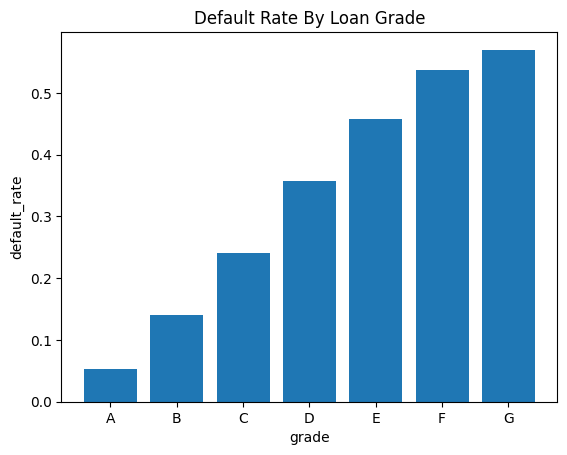

In [17]:
plt.bar(grade_default['grade'] ,grade_default['default_rate']) 
plt.title("Default Rate By Loan Grade")
plt.xlabel("grade")
plt.ylabel("default_rate")
plt.show()

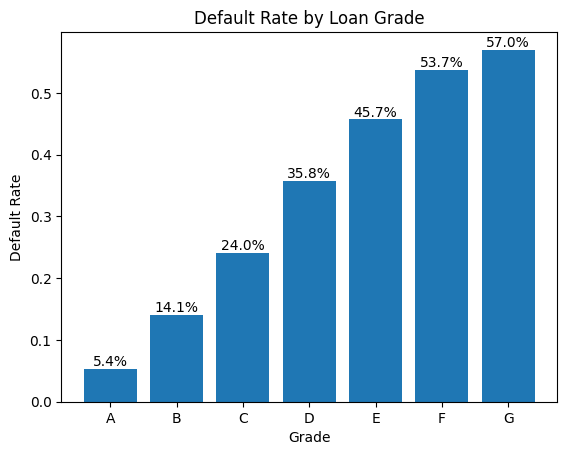

In [18]:
bars = plt.bar(grade_default['grade'], grade_default['default_rate'])

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width() / 2,  
        bar.get_height() + 0.005,            
        f"{bar.get_height() * 100:.1f}%",                                  
        ha='center'
    )

plt.title('Default Rate by Loan Grade')
plt.xlabel('Grade')
plt.ylabel('Default Rate')
plt.show()

In [19]:
df['fico_mid'] = (df['fico_range_low'] + df['fico_range_high'])/2
df['fico_mid'].describe()

count    44252.000000
mean       696.295715
std         31.152960
min        662.000000
25%        672.000000
50%        687.000000
75%        712.000000
max        847.500000
Name: fico_mid, dtype: float64

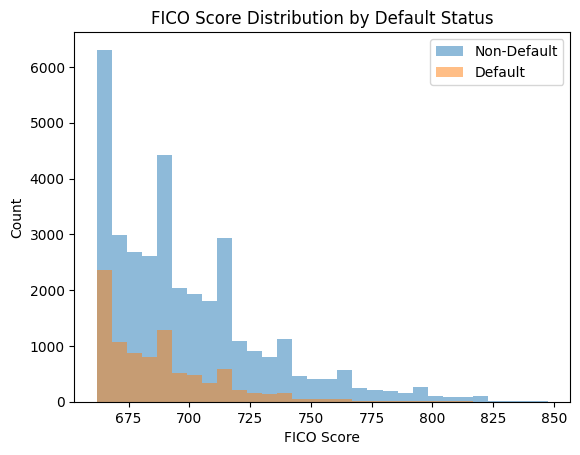

In [20]:
plt.hist(df[df['target'] == 0]['fico_mid'], bins=30, alpha=0.5, label='Non-Default')
plt.hist(df[df['target'] == 1]['fico_mid'], bins=30, alpha=0.5, label='Default')
plt.title('FICO Score Distribution by Default Status')
plt.xlabel('FICO Score')
plt.ylabel('Count')
plt.legend()
plt.show()

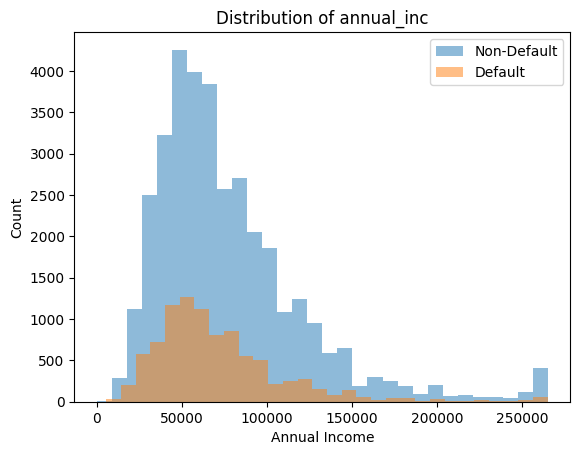

In [21]:
plt.hist(df[df['target'] == 0]['annual_inc'], bins=30, alpha=0.5, label='Non-Default')
plt.hist(df[df['target'] == 1]['annual_inc'], bins=30, alpha=0.5, label='Default')
plt.title('Distribution of annual_inc')
plt.xlabel('Annual Income')
plt.ylabel('Count')
plt.legend() 
plt.show()

In [22]:
numeric_df = df.select_dtypes(include=['number'])
corr_matrix =numeric_df.corr()
print(corr_matrix.shape)

(61, 61)


In [23]:
target_corr = corr_matrix['target'].abs().sort_values(ascending=False)
print(target_corr.head(15))

target                  1.000000
last_fico_range_high    0.697441
last_fico_range_low     0.599896
int_rate                0.314613
fico_range_low          0.139033
fico_mid                0.139032
fico_range_high         0.139030
acc_open_past_24mths    0.136083
dti                     0.123638
num_tl_op_past_12m      0.115360
inq_last_6mths          0.099439
bc_open_to_buy          0.086406
avg_cur_bal             0.082550
loan_amnt               0.080706
funded_amnt             0.080706
Name: target, dtype: float64


In [24]:
top_features = target_corr.head(15).index.tolist()
top_features

['target',
 'last_fico_range_high',
 'last_fico_range_low',
 'int_rate',
 'fico_range_low',
 'fico_mid',
 'fico_range_high',
 'acc_open_past_24mths',
 'dti',
 'num_tl_op_past_12m',
 'inq_last_6mths',
 'bc_open_to_buy',
 'avg_cur_bal',
 'loan_amnt',
 'funded_amnt']

In [25]:
top_features.remove('target')

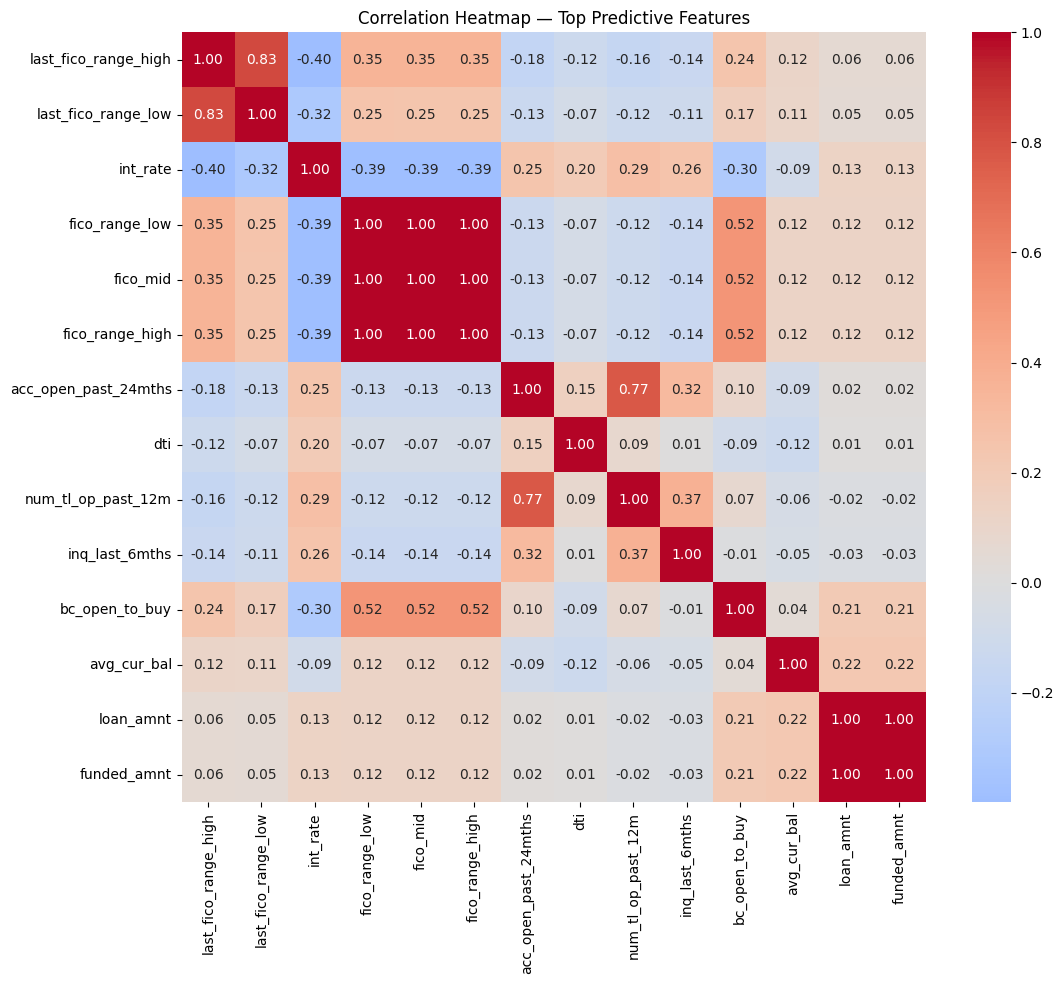

In [26]:
plt.figure(figsize=(12, 10))
sns.heatmap(df[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap — Top Predictive Features')
plt.show()

CREDIT RISK INTELLIGENCE SYSTEM — Full Decision Log

THE BUSINESS PROBLEM
Predict whether a borrower will default on a LendingClub loan before the loan is issued. A lender has two costly mistakes — approving someone who defaults (loses money) and rejecting someone who would have paid (loses revenue). The model needs to minimize both.

DATASET

Started with 50,000 rows, 151 columns
Final clean dataset: 44,252 rows, 76 columns


TARGET VARIABLE

Binary 0/1 — 1 means default, 0 means paid off
20.96% default rate — class imbalance exists, will need to handle during modeling


COLUMNS DROPPED AND WHY
57 high-missing columns dropped — columns missing more than a threshold of data are unreliable. A model can't learn from data that isn't there, and imputing heavily missing columns introduces more noise than signal.
12 leakage columns dropped — these columns contain information that would only be available after the loan outcome is known. Using them would make the model look accurate in training but fail completely in production. Example: last_fico_range_high — this is the borrower's FICO score recorded after the loan was issued, possibly right before they defaulted. In production you only have the FICO score at origination.
8 identifier columns dropped — columns like id and member_id are unique per row. A model trained on them would memorize row numbers, not learn patterns. Zero predictive value.

OUTLIER TREATMENT AND WHY
annual_inc capped at $265,000 — extreme income outliers (one person earning $9M) would distort model training. Tree-based models handle outliers better than linear models, but capping at the 99th percentile is standard practice. Business reason: a $9M income borrower is not representative of LendingClub's customer base.
dti values above 100 nulled — debt-to-income ratio above 100 means debt exceeds income by more than 100%. Mathematically possible but almost certainly a data entry error. Nulling is safer than capping because these values are likely wrong, not just extreme.
revol_util capped at 100% — revolving utilization above 100% is impossible by definition. Values above 100 are data errors, capped at 100.
1 zero income row removed — a borrower with zero income is either a data error or an edge case so rare it adds no value to training.

EDA FINDINGS AND BUSINESS IMPLICATIONS
Default rate by loan grade:

Grade A: 5.4% → Grade G: 57%
Clean ascending pattern confirms target variable is correctly defined
Business implication: expected losses nearly triple from Grade A to Grade B at $15,000 average loan size. Grade is the single strongest categorical predictor.

FICO score distribution:

Defaulters cluster at lower FICO scores (660–680 range)
Heavy overlap between defaulters and non-defaulters
Business implication: FICO alone can't separate defaulters. Useful signal but insufficient standalone. Median FICO of defaulters is roughly 60–70 points lower than non-defaulters.

Income distribution:

Both groups peak at $40,000–$60,000
Very heavy overlap — weakest signal of the three plots
Business implication: income alone is a poor predictor of default. A high earner can still default due to high debt, job loss, or poor financial behavior. This is why DTI (debt-to-income ratio) will be more useful than raw income.

Correlation heatmap:

last_fico_range_high (0.70) and last_fico_range_low (0.60) — strongest correlations with target but leakage. Will not be used as model features.
int_rate (0.31) — strong legitimate predictor. LendingClub charges higher rates to riskier borrowers, creating a feedback signal.
fico_range_low, fico_mid, fico_range_high — perfectly correlated at 1.00 with each other. Keep only fico_range_low, drop the other two.
loan_amnt and funded_amnt — perfectly correlated at 1.00. Same signal twice. Drop funded_amnt, keep loan_amnt.
acc_open_past_24mths and num_tl_op_past_12m — correlated at 0.77. Both measure recent credit activity. Will revisit during feature engineering.

In [27]:
print("Shape before:", df.shape)

df.drop(['last_fico_range_high', 'last_fico_range_low', 'fico_mid', 'fico_range_high', 'funded_amnt'], axis=1, inplace=True)

print("Shape after:", df.shape)

Shape before: (44252, 77)
Shape after: (44252, 72)


In [28]:
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
print(df['loan_to_income'].describe())

count    4.425200e+04
mean              inf
std               NaN
min      4.622642e-03
25%      1.215358e-01
50%      1.948052e-01
75%      2.857143e-01
max               inf
Name: loan_to_income, dtype: float64


c:\Users\Zakir Elaskar\credit-risk-system\.venv\lib\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [29]:
(df['annual_inc'] == 0).sum()

np.int64(1)

In [30]:
df = df[df['annual_inc'] != 0]
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
print(df['loan_to_income'].describe())

count    44251.000000
mean         0.209946
std          0.114474
min          0.004623
25%          0.121533
50%          0.194805
75%          0.285714
max          3.700565
Name: loan_to_income, dtype: float64


In [31]:
df = df[df['annual_inc'] != 0]
df['loan_to_income'] = df['loan_amnt'] / df['annual_inc']
print(df['loan_to_income'].describe())

count    44251.000000
mean         0.209946
std          0.114474
min          0.004623
25%          0.121533
50%          0.194805
75%          0.285714
max          3.700565
Name: loan_to_income, dtype: float64


In [32]:
'revol_util' in df.columns
print(df['revol_util'].describe())

count    44003.000000
mean        51.067875
std         23.946434
min          0.000000
25%         33.100000
50%         50.800000
75%         69.400000
max        100.000000
Name: revol_util, dtype: float64


In [33]:
'dti' in df.columns
print(df['dti'].describe())

count    44248.000000
mean        19.067492
std          8.720174
min          0.000000
25%         12.430000
50%         18.540000
75%         25.320000
max         90.000000
Name: dti, dtype: float64


In [34]:
df['loan_to_fico'] = df['loan_amnt'] / df['fico_range_low']
print(df['loan_to_fico'].describe())

count    44251.000000
mean        20.642111
std         12.337372
min          1.219512
25%         11.088591
50%         17.910448
75%         28.666667
max         53.030303
Name: loan_to_fico, dtype: float64


In [35]:
grade_map = {'A': 1, 'B': 2, 'C': 3, 'D': 4, 'E': 5, 'F': 6, 'G': 7}
df['grade'] = df['grade'].map(grade_map)
print(df['grade'].value_counts().sort_index())

grade
1     8422
2    13935
3    12313
4     5728
5     2813
6      847
7      193
Name: count, dtype: int64


In [36]:
df = pd.get_dummies(df, columns=['home_ownership', 'purpose'])
df
print(df.shape)

(44251, 88)


In [37]:
print([col for col in df.columns if 'home_ownership' in col or 'purpose' in col])

['home_ownership_ANY', 'home_ownership_MORTGAGE', 'home_ownership_OWN', 'home_ownership_RENT', 'purpose_car', 'purpose_credit_card', 'purpose_debt_consolidation', 'purpose_home_improvement', 'purpose_house', 'purpose_major_purchase', 'purpose_medical', 'purpose_moving', 'purpose_other', 'purpose_renewable_energy', 'purpose_small_business', 'purpose_vacation']


In [38]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))

mths_since_last_delinq    21141
mths_since_recent_inq      4527
emp_title                  2768
emp_length                 2763
num_tl_120dpd_2m           2423
mo_sin_old_il_acct         1236
percent_bc_gt_75            456
bc_util                     439
bc_open_to_buy              413
mths_since_recent_bc        397
revol_util                  248
dti                           3
dtype: int64


In [39]:
df['mths_since_last_delinq'].fillna(999)
df['mths_since_recent_inq'].fillna(999)
df['mths_since_recent_bc'].fillna(999)
df['mo_sin_old_il_acct'].fillna(999)

print(df[['mths_since_last_delinq', 'mths_since_recent_inq', 'mths_since_recent_bc', 'mo_sin_old_il_acct']].isnull().sum())

mths_since_last_delinq    21141
mths_since_recent_inq      4527
mths_since_recent_bc        397
mo_sin_old_il_acct         1236
dtype: int64


In [40]:
df = df.drop(columns=['emp_title'])
df['num_tl_120dpd_2m'] = df['num_tl_120dpd_2m'].fillna(df['num_tl_120dpd_2m'].median())
df['percent_bc_gt_75'] = df['percent_bc_gt_75'].fillna(df['percent_bc_gt_75'].median())
df['bc_util'] = df['bc_util'].fillna(df['bc_util'].median())
df['bc_open_to_buy'] = df['bc_open_to_buy'].fillna(df['bc_open_to_buy'].median())
df['revol_util'] = df['revol_util'].fillna(df['revol_util'].median())
df['dti'] = df['dti'].fillna(df['dti'].median())

# Verify
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0].sort_values(ascending=False))
print("Shape:", df.shape)

mths_since_last_delinq    21141
mths_since_recent_inq      4527
emp_length                 2763
mo_sin_old_il_acct         1236
mths_since_recent_bc        397
dtype: int64
Shape: (44251, 87)


In [41]:
print(df['emp_length'].unique())

['10+ years' '3 years' '4 years' '6 years' '7 years' '8 years' '2 years'
 '5 years' '9 years' '< 1 year' '1 year' nan]


In [42]:
emp_map = {'< 1 year': 0, '1 year': 1, '2 years': 2, '3 years': 3, '4 years': 4, '5 years': 5, '6 years': 6, '7 years': 7, '8 years': 8, '9 years': 9, '10+ years': 10}
df['emp_length'] = df['emp_length'].map(emp_map)
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())
print(df['emp_length'].isnull().sum())
print(df.shape)

0
(44251, 87)


In [43]:
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0])

mths_since_last_delinq    21141
mo_sin_old_il_acct         1236
mths_since_recent_bc        397
mths_since_recent_inq      4527
dtype: int64


In [44]:
df['emp_length'] = df['emp_length'].fillna(df['emp_length'].median())
print(df['emp_length'].isnull().sum())

0


In [45]:
import os
os.makedirs('credit-risk-system/data/processed', exist_ok=True)
df.to_parquet('credit-risk-system/data/processed/engineered_loans.parquet')


In [46]:
print("Saved successfully")

Saved successfully


In [47]:
import os
print(os.path.exists('credit-risk-system/data/processed/engineered_loans.parquet'))

True


In [48]:
import pandas as pd  
df = pd.read_parquet('credit-risk-system/data/processed/engineered_loans.parquet')
print(df.shape)
print(df.columns.tolist())

(44251, 87)
['loan_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_length', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_sats', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_

In [49]:
import os
print(os.getcwd())

c:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\notebooks


In [50]:
import os
print(os.listdir('..'))

['data', 'DECISIONS.md', 'notebooks', 'src']


In [51]:
import os
print(os.listdir('../..'))

['.git', '.gitignore', '.venv', 'credit-risk-system', 'README.md']


In [52]:
import subprocess
result = subprocess.run(['dir', '/s', '/b', 'accepted_2007_to_2018Q4.csv.gz'], shell=True, cwd='../../..', capture_output=True, text=True)
print(result.stdout)

c:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\data\raw\accepted_2007_to_2018Q4.csv.gz



In [53]:
import subprocess
result = subprocess.run(['dir', '/s', '/b', 'engineered_loans.parquet'], shell=True, cwd='C:\\Users\\Zakir Elaskar', capture_output=True, text=True)
print(result.stdout)

C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\data\processed\engineered_loans.parquet
C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\notebooks\credit-risk-system\data\processed\engineered_loans.parquet



In [54]:
import os
for root, dirs, files in os.walk('C:\\Users\\Zakir Elaskar\\credit-risk-system'):
    # skip virtual env and git internals — too noisy
    dirs[:] = [d for d in dirs if d not in ('.venv', '.git')]
    level = root.replace('C:\\Users\\Zakir Elaskar\\credit-risk-system', '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    for f in files:
        print(f'{indent}  {f}')

credit-risk-system/
  .gitignore
  README.md
  credit-risk-system/
    DECISIONS.md
    data/
      processed/
        engineered_loans.parquet
      raw/
        accepted_2007_to_2018Q4.csv.gz
    notebooks/
      01_eda.ipynb
      02_modeling.ipynb
      correlation_heatmap.png
      default_rates_categorical.png
      distributions_by_target.png
      credit-risk-system/
        data/
          processed/
            engineered_loans.parquet
    src/
      eda_output.txt
      eda_output_utf8.txt
      eda_steps.py


In [55]:
import shutil

# Move data folder up to sit next to notebooks and src
shutil.move(
    r'C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\notebooks\credit-risk-system\data',
    r'C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\data'
)

# Remove the now-empty stray folder
os.rmdir(r'C:\Users\Zakir Elaskar\credit-risk-system\credit-risk-system\notebooks\credit-risk-system')

print("Done")

Done
